In [28]:
import qiskit
from qiskit import QuantumCircuit, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFTGate
from qiskit import transpile
from qiskit.visualization import plot_histogram
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt

In [29]:
#load image
def load_image(filename):
    im = Image.open(filename,'r')
    im = im.convert('L') #convert to grayscale
    return np.array(im)

In [30]:
#encode image into quantum state
def encode_image(filename, n_qubits):
    #open image file in greyscale and form normalized array
    pixel_value_array = load_image(filename).flatten()
    
    #Normalize the pixel values
    norm = np.linalg.norm(pixel_value_array)
    norm_array = pixel_value_array/norm


    #translate normalized array into qubits
    
    qc = QuantumCircuit(n_qubits)
    qc.initialize(norm_array, qc.qubits)
    return qc,norm_array
    

In [31]:
#reconstruct image from the circuit
def measure_image(qc, n_qubits,shots = 200000):
    #perform measurement on the circuit
    qc.measure_all()
    aer_sim = AerSimulator()
    decomposed_qc = qc.decompose() 
    t_qc = transpile(decomposed_qc, aer_sim)
    result = aer_sim.run(t_qc,shots=shots).result()
    counts = result.get_counts()

    #construct measured image
    measured_arr = np.zeros(2**n_qubits,dtype=float)
    bin_var = 0b0000
    dict_keys = counts.keys()
    for i in range(2**n_qubits):
        #generate str representation of each state
        str_var = bin(bin_var)[2:]
        str_var = str_var.zfill(n_qubits)
        #if in counts, fill array with avg value
        if str_var in dict_keys:
            measured_arr[i] = counts[f'{str_var}']/shots
            #take sqrt to convert probability to the amplitude
            measured_arr[i] = np.sqrt(measured_arr[i])
        else:
            measured_arr[i] = 0
        bin_var += 1

    #convert back into RGB
    measured_arr = measured_arr * 255
    size = int(np.sqrt(2**n_qubits))
    measured_arr = measured_arr.reshape((size, size))
    return measured_arr
    
    

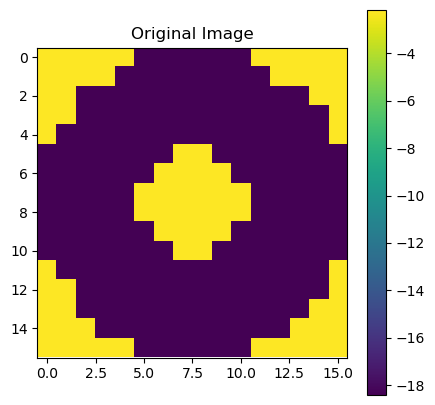

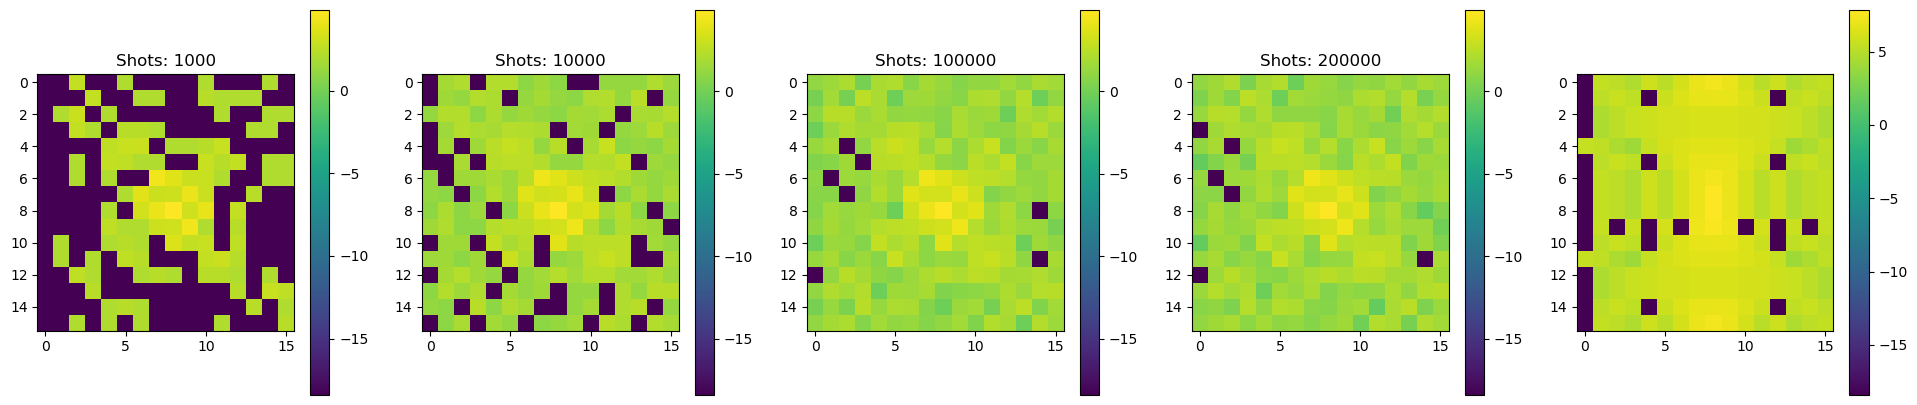

In [ ]:
#QFT on image
c = 1e-8 #to avoid log(0) error when plotting
qc,norm_arr = encode_image('circle.png', 8)
qc.append(QFTGate(8), qc.qubits)
# display the circuit
shots = np.array([1000, 10000, 100000, 200000])
plt.figure(figsize=(5, 5))
plt.imshow(np.log(norm_arr.reshape((16,16)) + c))
plt.colorbar()
plt.title('Original Image')
plt.show()

plt.figure(figsize=(24, 5))
for i in range(len(shots)):
    measured_arr = measure_image(qc, 8, shots = shots[i])
    shifted_image = np.fft.fftshift(measured_arr)
    plt.subplot(1, len(shots)+1, i + 1)
    plt.imshow(np.log(shifted_image + c))
    plt.colorbar()
    plt.title(f'FFT: Shots: {shots[i]}')
    
    qc,norm_arr = encode_image('circle.png', 8)
    qc.append(QFTGate(8), qc.qubits)

#classical FT
im = load_image('circle.png')
f_transform = np.fft.fft(im)
f_shift = np.fft.fftshift(f_transform)
magnitude_spectrum = np.log(np.abs(f_shift) + c)
plt.subplot(1, len(shots) + 1, len(shots) + 1)
plt.imshow(magnitude_spectrum)
plt.colorbar()
plt.show()

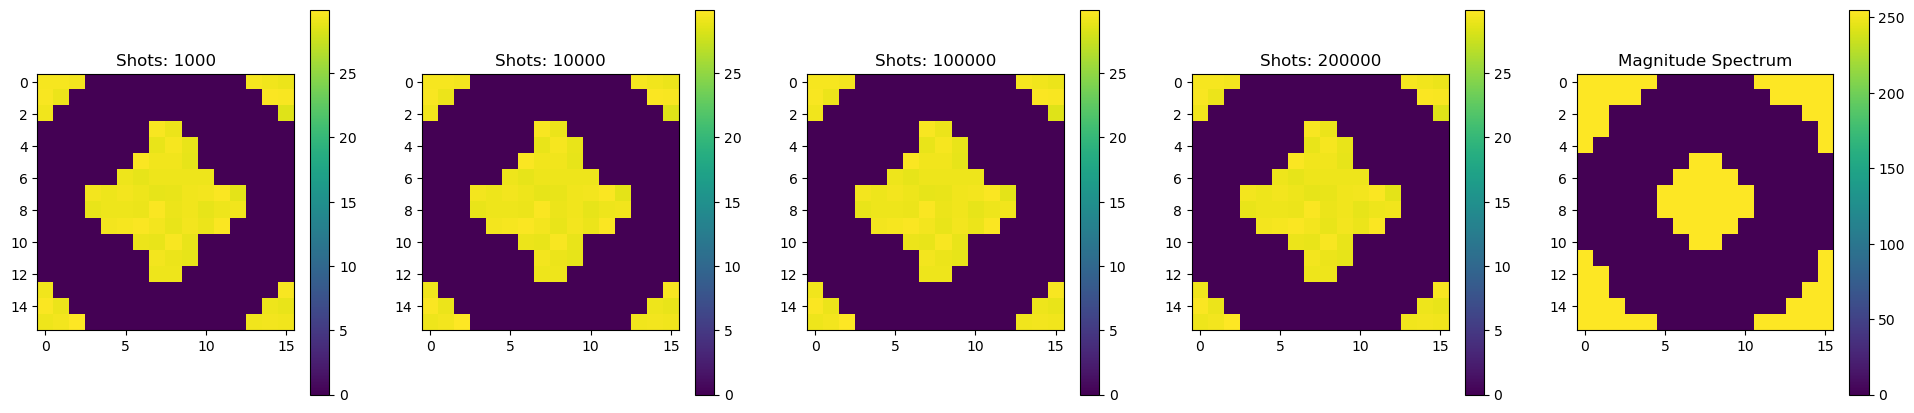

In [58]:
# transform to the spatial domain
# inverse QFT
inverse_f_transform = np.fft.ifft(f_transform)
magnitude_spectrum = np.abs(inverse_f_transform)
plt.figure(figsize=(24, 5))
plt.subplot(1, len(shots) + 1, len(shots) + 1)
plt.imshow(magnitude_spectrum)
plt.colorbar()
plt.title('Magnitude Spectrum')
for i in range(len(shots)):
    qc,norm_arr = encode_image('circle.png', 8)
    qc.append(QFTGate(8), qc.qubits)
    qc.append(QFTGate(8).inverse(), qc.qubits)
    measured_arr = measure_image(qc, 8, shots = shots[i])
    # shifted_image = np.fft.fftshift(measured_arr)
    plt.subplot(1, len(shots)+1, i + 1)
    plt.imshow(shifted_image)
    plt.colorbar()
    plt.title(f'Shots: {shots[i]}')
        

plt.show()

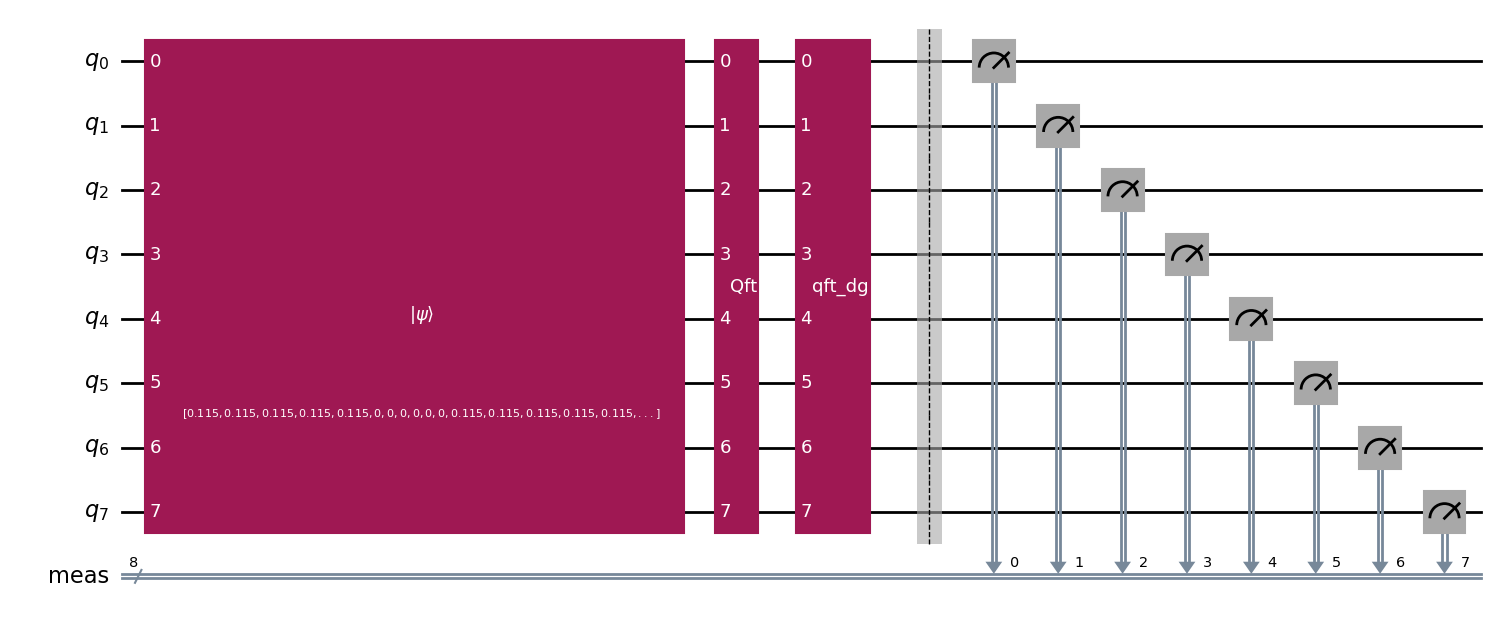

In [47]:
qc.draw('mpl')

### Quantum advantage
Less time, less energy, more accurate results


### Quaestions
Do we need to write down the circuits by hand from the simplest gates?

### Next steps
1. Make decoding.
2. Apply kernles in fourier domain.
3. Try colored images.
4. Measure quantum advantage.